# EXP-002 — Feature Engineering
StandardScaler → FFT (16 spectral) + UMAP (3 temporal) → 19-feature matrix

In [1]:
import sys
sys.path.insert(0, str(__import__('pathlib').Path('..').resolve()))

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from src.beed.data import load_raw, split
from src.beed.features import build_features, fft_features, scale
from src.beed.config import CLASS_LABELS, CHANNEL_NAMES, DATA_PROCESSED, FIGURES

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
sns.set_theme(style='whitegrid')
print('Ready.')

Ready.


## 1. Load & split

In [2]:
df = load_raw()
train, val, test = split(df)

X_train = train.drop(columns=['y'])
y_train = train['y']
X_val   = val.drop(columns=['y'])
y_val   = val['y']
X_test  = test.drop(columns=['y'])
y_test  = test['y']

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')

Train: (5600, 16)  Val: (800, 16)  Test: (1600, 16)


## 2. Verify FFT axis: shape must be preserved

In [3]:
X_scaled_check, _ = scale(X_train, fit=True)
fft_check = fft_features(X_scaled_check)

print(f'Input shape  : {X_scaled_check.shape}')
print(f'FFT output   : {fft_check.shape}')
assert fft_check.shape == X_scaled_check.shape, 'FFT must preserve (n_samples, 16)'
print('Shape check passed.')

# Confirm FFT[0] is always the DC term (sum of values) — real, non-negative
dc = fft_check.iloc[:, 0]
print(f'\nDC term (k=0) stats: min={dc.min():.3f}  max={dc.max():.3f}  all>=0: {(dc >= 0).all()}')

Input shape  : (5600, 16)
FFT output   : (5600, 16)
Shape check passed.

DC term (k=0) stats: min=0.000  max=62.136  all>=0: True


## 3. Build 19-feature matrix (fit on train)

In [4]:
print('Fitting scaler + UMAP on train set (this takes ~30-60s)...')
feat_train, fitted_scaler, fitted_umap = build_features(X_train, fit=True)

print(f'\nTrain features shape: {feat_train.shape}')
assert feat_train.shape == (len(X_train), 19), f'Expected (n, 19), got {feat_train.shape}'
print(f'Columns: {list(feat_train.columns)}')

Fitting scaler + UMAP on train set (this takes ~30-60s)...


C:\dev\BEED\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Train features shape: (5600, 19)
Columns: ['Fp1_fft', 'Fp2_fft', 'F3_fft', 'F4_fft', 'C3_fft', 'C4_fft', 'P3_fft', 'P4_fft', 'O1_fft', 'O2_fft', 'F7_fft', 'F8_fft', 'T3_fft', 'T4_fft', 'T5_fft', 'T6_fft', 'umap_1', 'umap_2', 'umap_3']


In [5]:
print('Transforming val and test sets...')
feat_val,  _, _ = build_features(X_val,  scaler=fitted_scaler, umap_reducer=fitted_umap, fit=False)
feat_test, _, _ = build_features(X_test, scaler=fitted_scaler, umap_reducer=fitted_umap, fit=False)

print(f'Val   features shape: {feat_val.shape}')
print(f'Test  features shape: {feat_test.shape}')
assert feat_val.shape[1] == 19
assert feat_test.shape[1] == 19
print('All shapes valid.')

Transforming val and test sets...


Val   features shape: (800, 19)
Test  features shape: (1600, 19)
All shapes valid.


## 4. Feature statistics

In [6]:
feat_train.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Fp1_fft,5600.0,5.297,8.099,0.000,0.978,2.175,5.010,62.136
Fp2_fft,5600.0,3.631,6.994,0.012,0.313,0.576,1.993,55.733
F3_fft,5600.0,1.707,2.492,0.005,0.328,0.624,1.698,24.758
F4_fft,5600.0,1.072,1.096,0.003,0.416,0.712,1.247,10.259
C3_fft,5600.0,1.479,1.228,0.010,0.660,1.122,1.894,9.861
C4_fft,5600.0,0.814,0.629,0.008,0.395,0.658,1.028,7.128
P3_fft,5600.0,0.829,0.621,0.004,0.390,0.672,1.090,6.357
P4_fft,5600.0,0.697,0.474,0.004,0.370,0.593,0.899,5.122
O1_fft,5600.0,1.045,1.033,0.000,0.356,0.765,1.364,7.754
O2_fft,5600.0,0.697,0.474,0.004,0.370,0.593,0.899,5.122


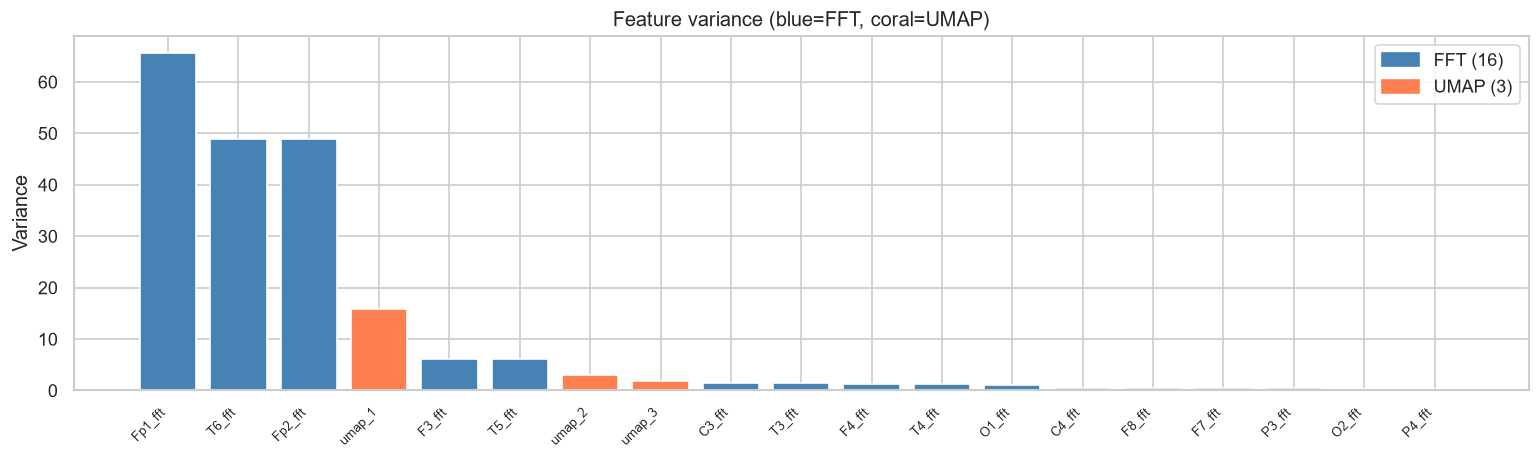

In [7]:
# Variance per feature — low variance = weak discriminator
var = feat_train.var().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(13, 4))
colors = ['steelblue' if '_fft' in c else 'coral' for c in var.index]
ax.bar(range(len(var)), var.values, color=colors)
ax.set_xticks(range(len(var)))
ax.set_xticklabels(var.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Variance')
ax.set_title('Feature variance (blue=FFT, coral=UMAP)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='FFT (16)'), Patch(color='coral', label='UMAP (3)')])
plt.tight_layout()
plt.savefig(FIGURES / '07_feature_variance.png')
plt.show()

## 5. FFT features — distribution per class

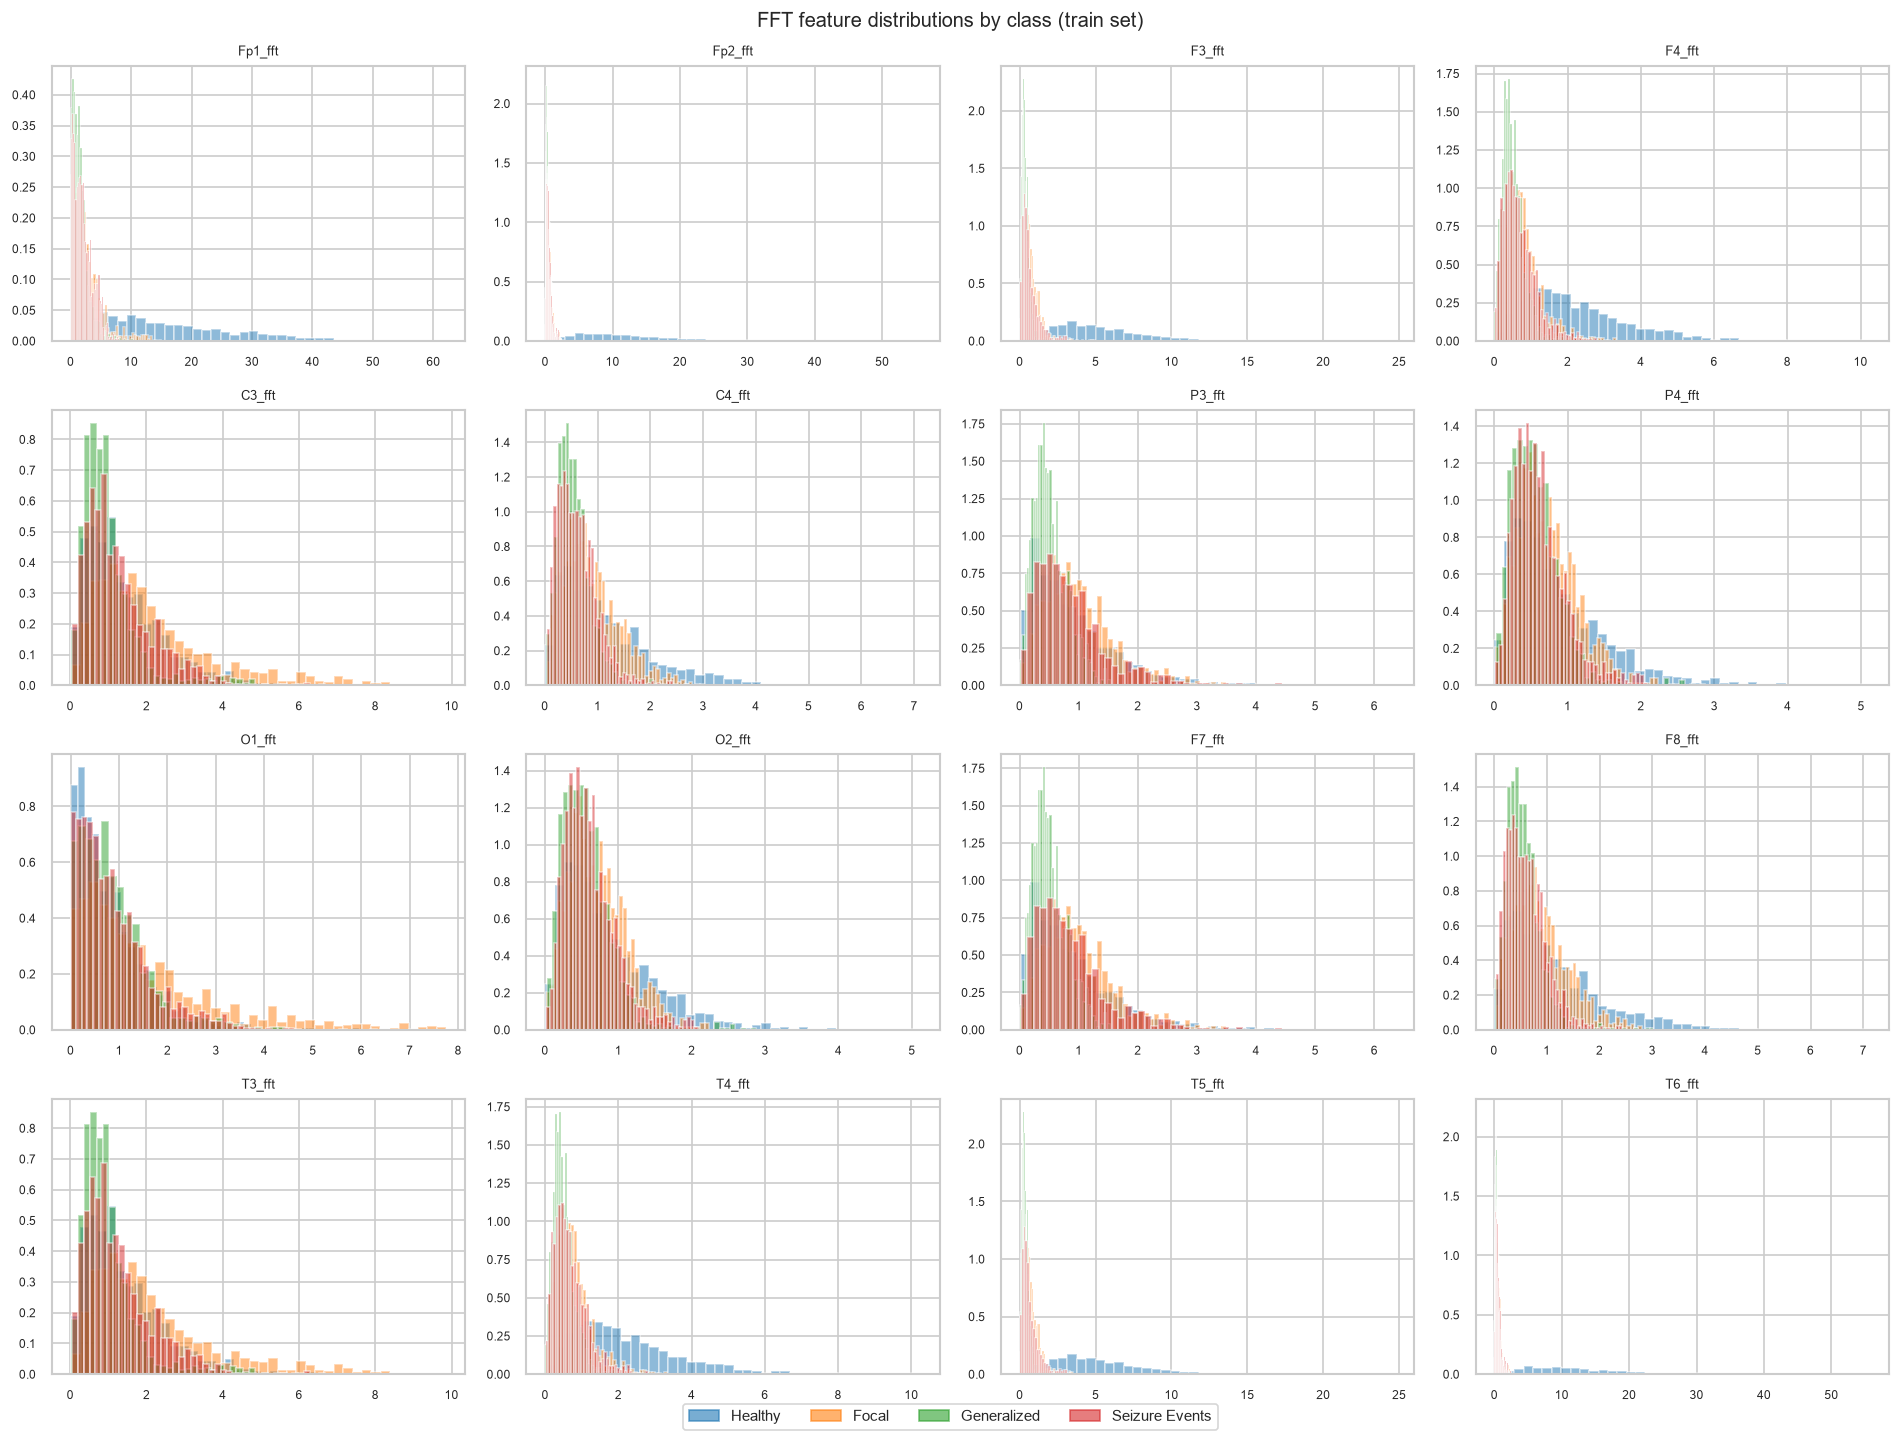

In [8]:
fft_cols = [c for c in feat_train.columns if '_fft' in c]
feat_with_y = feat_train.assign(y=y_train.values)

fig, axes = plt.subplots(4, 4, figsize=(16, 12), sharey=False)
palette = sns.color_palette('tab10', 4)

for ax, col in zip(axes.ravel(), fft_cols):
    for cls, color in zip(sorted(y_train.unique()), palette):
        vals = feat_with_y[feat_with_y['y'] == cls][col]
        ax.hist(vals, bins=40, alpha=0.5, color=color, density=True, label=CLASS_LABELS[cls])
    ax.set_title(col, fontsize=8)
    ax.tick_params(labelsize=7)

handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.6) for c in palette]
fig.legend(handles, [CLASS_LABELS[c] for c in sorted(y_train.unique())],
           loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.01))
fig.suptitle('FFT feature distributions by class (train set)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / '08_fft_distributions.png', bbox_inches='tight')
plt.show()

## 6. UMAP embedding — 2D projections coloured by class

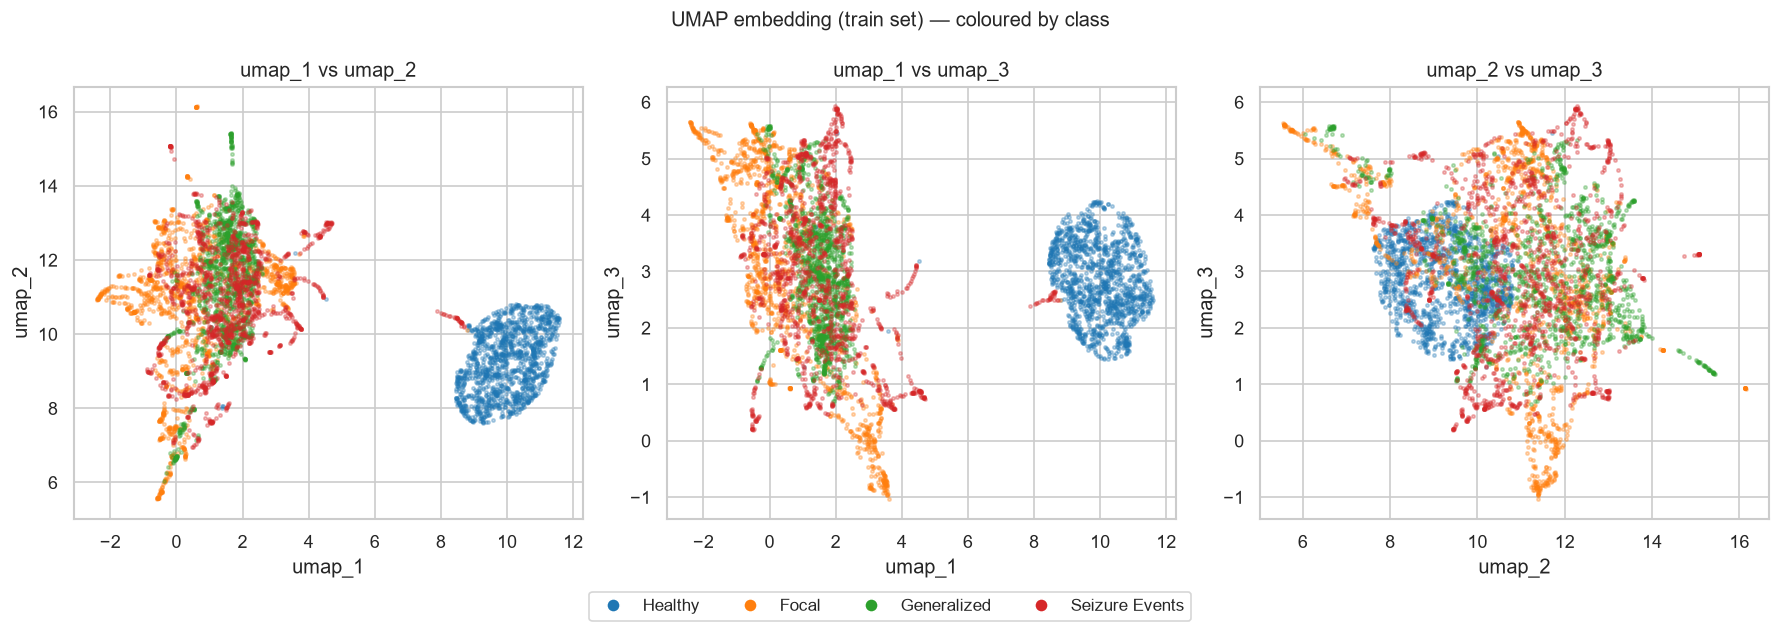

In [9]:
umap_cols = ['umap_1', 'umap_2', 'umap_3']
pairs = [('umap_1', 'umap_2'), ('umap_1', 'umap_3'), ('umap_2', 'umap_3')]
palette = sns.color_palette('tab10', 4)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (xa, ya) in zip(axes, pairs):
    for cls, color in zip(sorted(y_train.unique()), palette):
        mask = y_train.values == cls
        ax.scatter(
            feat_train.loc[mask, xa],
            feat_train.loc[mask, ya],
            c=[color], alpha=0.3, s=4, label=CLASS_LABELS[cls]
        )
    ax.set_xlabel(xa)
    ax.set_ylabel(ya)
    ax.set_title(f'{xa} vs {ya}')

handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=8)
           for c in palette]
fig.legend(handles, [CLASS_LABELS[c] for c in sorted(y_train.unique())],
           loc='lower center', ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.05))
fig.suptitle('UMAP embedding (train set) — coloured by class', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / '09_umap_embedding.png', bbox_inches='tight')
plt.show()

## 7. Class separability: per-feature ANOVA F-score

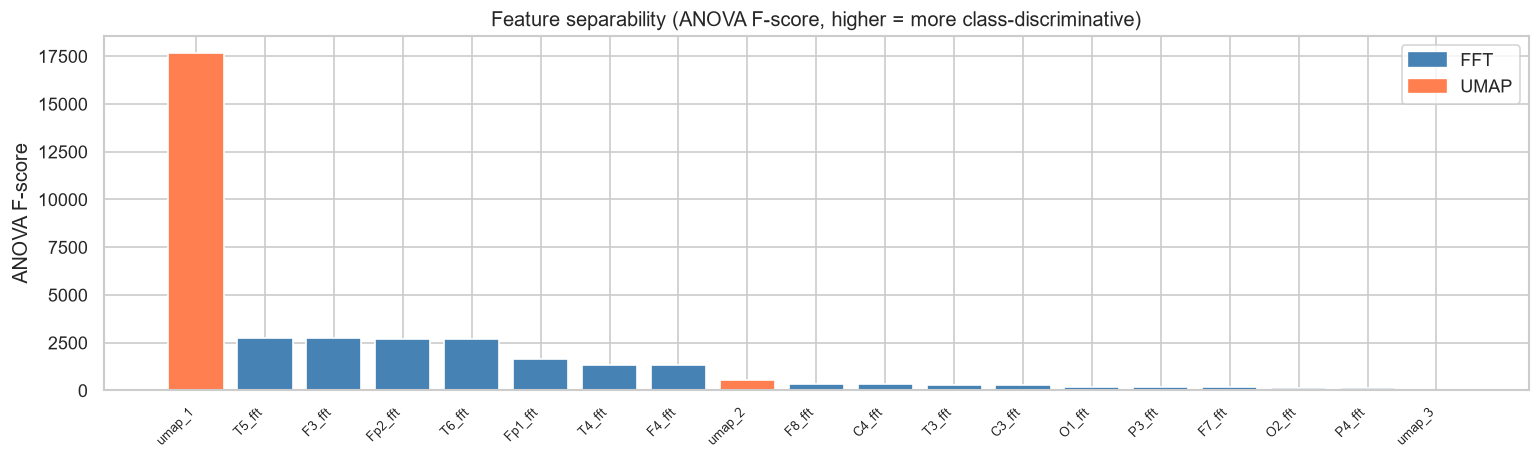

Top 5 most discriminative features:
   feature       F_score  p_value
0   umap_1  17664.891851      0.0
1   T5_fft   2758.474839      0.0
2   F3_fft   2758.474839      0.0
3  Fp2_fft   2718.619864      0.0
4   T6_fft   2718.619864      0.0


In [10]:
from sklearn.feature_selection import f_classif

F, p = f_classif(feat_train, y_train)
sep = pd.DataFrame({'feature': feat_train.columns, 'F_score': F, 'p_value': p})
sep = sep.sort_values('F_score', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 4))
colors = ['steelblue' if '_fft' in c else 'coral' for c in sep['feature']]
ax.bar(range(len(sep)), sep['F_score'], color=colors)
ax.set_xticks(range(len(sep)))
ax.set_xticklabels(sep['feature'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('ANOVA F-score')
ax.set_title('Feature separability (ANOVA F-score, higher = more class-discriminative)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='FFT'), Patch(color='coral', label='UMAP')])
plt.tight_layout()
plt.savefig(FIGURES / '10_feature_fscore.png')
plt.show()

print('Top 5 most discriminative features:')
print(sep.head())

## 8. Save processed features

In [11]:
feat_train.assign(y=y_train.values).to_parquet(DATA_PROCESSED / 'train_features.parquet', index=False)
feat_val.assign(y=y_val.values).to_parquet(DATA_PROCESSED / 'val_features.parquet', index=False)
feat_test.assign(y=y_test.values).to_parquet(DATA_PROCESSED / 'test_features.parquet', index=False)

with open(DATA_PROCESSED / 'scaler.pkl', 'wb') as f:
    pickle.dump(fitted_scaler, f)
with open(DATA_PROCESSED / 'umap_reducer.pkl', 'wb') as f:
    pickle.dump(fitted_umap, f)

print('Saved:')
for p in sorted(DATA_PROCESSED.iterdir()):
    print(f'  {p.name}  ({p.stat().st_size / 1024:.0f} KB)')

Saved:
  .gitkeep  (0 KB)
  scaler.pkl  (1 KB)
  test_features.parquet  (272 KB)
  train_features.parquet  (948 KB)
  umap_reducer.pkl  (3882 KB)
  val_features.parquet  (140 KB)


## 9. Summary

In [12]:
print('=== EXP-002 Summary ===')
print(f'Pipeline      : StandardScaler → FFT (axis=1) + UMAP({fitted_umap.n_components}D)')
print(f'Train features: {feat_train.shape}')
print(f'Val   features: {feat_val.shape}')
print(f'Test  features: {feat_test.shape}')
print(f'\nTop discriminative feature : {sep.iloc[0]["feature"]}  (F={sep.iloc[0]["F_score"]:.1f})')
print(f'Least discriminative feature: {sep.iloc[-1]["feature"]}  (F={sep.iloc[-1]["F_score"]:.1f})')
print(f'\nAll features significant (p<0.05): {(sep["p_value"] < 0.05).all()}')

umap_f = sep[sep['feature'].str.startswith('umap_')]['F_score']
fft_f  = sep[sep['feature'].str.endswith('_fft')]['F_score']
print(f'\nMean F-score — FFT features : {fft_f.mean():.1f}')
print(f'Mean F-score — UMAP features: {umap_f.mean():.1f}')

=== EXP-002 Summary ===
Pipeline      : StandardScaler → FFT (axis=1) + UMAP(3D)
Train features: (5600, 19)
Val   features: (800, 19)
Test  features: (1600, 19)

Top discriminative feature : umap_1  (F=17664.9)
Least discriminative feature: umap_3  (F=5.1)

All features significant (p<0.05): True

Mean F-score — FFT features : 1083.6
Mean F-score — UMAP features: 6063.6
